In [292]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math

In [293]:
# ==========================================
# 1. LEER ARCHIVO Y RECORTAR DATOS ( 2.35 eV aprox)
# ==========================================
nombre_archivo = r'oXy_100_3.dat'

try:
    datos = np.genfromtxt(nombre_archivo, skip_header=0, delimiter=None)
    x_exp_full = datos[:, 0]
    y_exp_full = datos[:, 1] / np.max(datos[:, 1]) # normalización de la intensidad
except Exception as e:
    print(f"❌ Error al leer: {e}")
    x_exp_full, y_exp_full = np.linspace(1.8, 3.2, 10), np.zeros(10)

mascara = (x_exp_full >= 2) & (x_exp_full <= 2.3) # recortamos las máscara
x_exp = x_exp_full[mascara]
y_exp = y_exp_full[mascara]

In [294]:
# ==========================================
# 2. DEFINICIÓN DEL MODELO (EXTENSIÓN SPANO )
# ==========================================

# Gm = Σλ^2n/n!(n − m) -- eq. 25 doi:10.1016/j.chemphys.2005.08.019 -- es un constante que depende de m (vibrational level) y n (vibrational quantum number)
# S = λ^2 -- es el factor de Huang-Rhys
def Gm(m, S):
    gm = 0
    # Para m=0 a 4, n hasta 10 
    for n in range(10):
        if n == m:
            continue
        term = ((S**n) / math.factorial(n)) / (n - m)
        gm += term
    return gm
 
def Gaussian_linewidth(x, mu, sigma):
    norm = 1.0 / (np.sqrt(2*np.pi*sigma**2))
    return norm * np.exp(-((x - mu)**2) / (2*sigma**2))

def modelo_D18(x, Amp, E0, sigma, W, S, Ep):
    y_total = np.zeros_like(x)
    picos = []
    
    for m in range(5):
        fc_factor = (np.exp(-S) * (S**m)) / math.factorial(m) # el primer término de la ecuación 2.  doi.org/10.1063/1.3110904

        term_spano = (1 - (W * np.exp(-S) / (2 * Ep)) * Gm(m, S))**2 # segundo término de la ecuación 2. doi.org/10.1063/1.3110904
        
        energia_m = E0 + m * Ep # el hw es el x en la gaussiana
        pico_m = Amp * fc_factor * term_spano * Gaussian_linewidth(x, energia_m, sigma)
        
        y_total += pico_m
        picos.append(pico_m)
        
    return y_total, picos

def modelo_D18_ajuste(x, Amp, E0, sigma, W, S, Ep):
    y_total, picos = modelo_D18(x, Amp, E0, sigma, W, S, Ep)
    return y_total

In [295]:
# ==========================================
# 3. AJUSTE CON LÍMITES FÍSICOS REALISTAS
# ==========================================
# [Amp, E0, sigma, W, S, Ep]
p0_estimado = [1, 2.12, 0.08, 0.05, 1.00, 0.17]
# Límites realistas para P3HT/D18:
# E0: posición del pico vibrónico
# sigma: la anchura de gaussiana
# W: acoplamiento excitónico intermolecular
# S: factor de Huang-Rhys
# Ep: energía vibracional del enlace principa
# Espacios limpiados aquí:
limites_inf = [0.01, 2.05, 0.01, 0.000, 0.500, 0.150] 
limites_sup = [100., 2.20, 0.20, 0.300, 2.000, 0.200]

parametros_optimos, covarianza = curve_fit(
    modelo_D18_ajuste, 
    x_exp, 
    y_exp, 
    p0=p0_estimado, 
    bounds=(limites_inf, limites_sup)
)

Amp_f, E0_f, sigma_f, W_f, S_f, Ep_f = parametros_optimos
print("¡Ajuste exitoso!")

¡Ajuste exitoso!


C:\Users\Jess\AppData\Local\Temp\ipykernel_21372\1252106526.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_diferencia = np.trapz(diferencia_abs, x=x_exp_full)


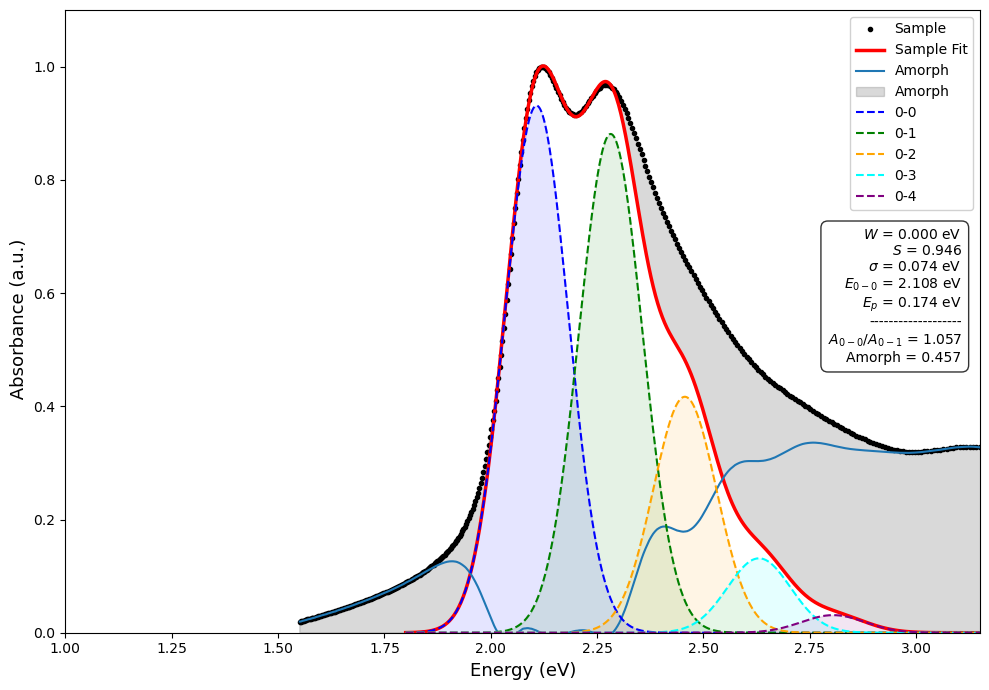

In [296]:
# ==========================================
# 4 y 5. CÁLCULO DE PROPIEDADES Y VISUALIZACIÓN
# ==========================================

ajuste_exitoso = True 
Amp_f, E0_f, sigma_f, W_f, S_f, Ep_f = parametros_optimos
# -----------------------------------------

if ajuste_exitoso:
    # 1. Cálculo de J (Acoplamiento excitónico)
    J_f = W_f / 4
    
    # 2. Cálculo de Relación de Intensidades A00/A01
    numerador = (1 - W_f * np.exp(-S_f) * Gm(0, S_f) / (2 * Ep_f))**2
    denominador = (1 - W_f * np.exp(-S_f) * Gm(1, S_f) / (2 * Ep_f))**2
    ratio_modelo = (1 / S_f) * numerador / denominador

    # --- NUEVO: CÁLCULO DEL ÁREA DE LA DIFERENCIA ---
    # Evaluamos el modelo en los puntos x experimentales para poder restar
    y_total_exp, _ = modelo_D18(x_exp_full, *parametros_optimos)
    # Calculamos la diferencia absoluta para que el área siempre sume el error total
    diferencia_abs = np.abs(y_exp_full - y_total_exp)
    # Calculamos el área integrando con la regla del trapecio
    area_diferencia = np.trapz(diferencia_abs, x=x_exp_full)
    # ------------------------------------------------

    # ==========================================
    # VISUALIZACIÓN (Cuadro de texto debajo de la leyenda)
    # ==========================================
    plt.figure(figsize=(10, 7)) 
    
    # 1. Dibujamos puntos experimentales
    plt.plot(x_exp_full, y_exp_full, 'ok', markersize=3, alpha=1, label='Sample')
    
    # 2. Curva total del ajuste
    x_plot_suave = np.linspace(1.80, 3.15, 500)
    y_total, picos = modelo_D18(x_plot_suave, *parametros_optimos)
    plt.plot(x_plot_suave, y_total, '-r', linewidth=2.5, label='Sample Fit')

    plt.plot(x_exp_full, y_exp_full-y_total_exp, label='Amorph')

    # --- NUEVO: DIBUJAR EL ÁREA DE LA DIFERENCIA ---
    # Sombreamos el espacio entre los datos experimentales y el modelo evaluado en esos mismos puntos
    plt.fill_between(x_exp_full, y_exp_full, y_total_exp, color='black', alpha=0.15, label='Amorph')
    # -----------------------------------------------
    
    # 3. Dibujamos SOLO los dos primeros picos (0-0 azul y 0-1 verde)
    colores_picos = ['blue', 'green', 'orange', 'cyan', 'purple']
    nombres = ['0-0', '0-1', '0-2', '0-3', '0-4']
    for i in range(5): 
        plt.plot(x_plot_suave, picos[i], '--', color=colores_picos[i], linewidth=1.5, label=f'{nombres[i]}')
        plt.fill_between(x_plot_suave, picos[i], color=colores_picos[i], alpha=0.1)
        
    # Configuración de etiquetas y títulos
    plt.xlabel('Energy (eV)', fontsize=13)
    plt.ylabel(' Absorbance (a.u.)', fontsize=13)
    #plt.title('Ajuste de Espectro de Absorción', fontsize=15)
    
    # Ajuste preciso de límites para dejar espacio a la derecha
    plt.xlim(1, 3.15) 
    ymax = np.max(y_exp_full) 
    plt.ylim(0, ymax * 1.1)
    
    # 4. Leyenda en la esquina superior derecha
    plt.legend(loc='upper right', framealpha=0.9)
    
    # 5. Cuadro de resultados por debajo de la leyenda
    # --- NUEVO: Añadido el Área Dif. al texto ---
    texto_res = (f"$W$ = {W_f:.3f} eV\n"
                 f"$S$ = {S_f:.3f}\n"
                 f"$\\sigma$ = {sigma_f:.3f} eV\n"
                 f"$E_{{0-0}}$ = {E0_f:.3f} eV\n"
                 f"$E_p$ = {Ep_f:.3f} eV\n"
                 f"-------------------\n"
                 f"$A_{{0-0}}/A_{{0-1}}$ = {ratio_modelo:.3f}\n"
                 f"Amorph = {area_diferencia:.3f}")
    
    # Posicionamos el texto
    plt.text(0.98, 0.65, texto_res, fontsize=10, 
             horizontalalignment='right',     
             verticalalignment='top',       
             transform=plt.gca().transAxes,  
             bbox=dict(facecolor='white', edgecolor='black', alpha=0.8, boxstyle='round,pad=0.5'))
    
    plt.tight_layout()
    plt.show()

In [297]:
# ==========================================
    # 6. EXPORTACIÓN DE DATOS A ARCHIVO TXT
    # ==========================================
print("Exportando curvas a archivo .txt...")
    
    # 1. Recalcular el modelo y los picos usando el eje X experimental (x_exp_full)
    # Esto es vital para que coincidan los puntos y se pueda calcular el residual (resta).
y_total_exp, picos_exp = modelo_D18(x_exp_full, *parametros_optimos)
    
    # 2. Calcular la resta (Curva Experimental - Modelo de Spano)
resta = y_exp_full - y_total_exp
    
    # 3. Agrupar todos los datos en columnas
    # Cada fila corresponderá a un valor de energía.
datos_exportar = np.column_stack((
    x_exp_full,      # Columna 1: Energía
    y_exp_full,      # Columna 2: Datos experimentales reales
    y_total_exp,     # Columna 3: Modelo de Spano total
    resta,           # Columna 4: Residual (Resta)
    picos_exp[0],    # Columna 5: Pico 0-0
    picos_exp[1],    # Columna 6: Pico 0-1
    picos_exp[2],    # Columna 7: Pico 0-2
    picos_exp[3],    # Columna 8: Pico 0-3
    picos_exp[4]     # Columna 9: Pico 0-4
))
    
    # 4. Crear el encabezado del archivo TXT (Nombres de las columnas)
encabezado = "Energia(eV)\tExperimental\tModelo_Spano\tResta(Exp-Mod)\tPico_0-0\tPico_0-1\tPico_0-2\tPico_0-3\tPico_0-4"
    
    # 5. Guardar el archivo usando tabulaciones (\t) como separador
nombre_archivo = "resultados_curvas_spano.txt"
np.savetxt(nombre_archivo, datos_exportar, delimiter="\t", header=encabezado, comments='', fmt="%.6f")
    
print(f"¡Datos guardados exitosamente en '{nombre_archivo}'!")

Exportando curvas a archivo .txt...
¡Datos guardados exitosamente en 'resultados_curvas_spano.txt'!
